In [1]:
#Load data (FD001)
import pandas as pd
import numpy as np

cols = ['unit', 'cycle'] + \
       [f'op_setting_{i}' for i in range(1,4)] + \
       [f'sensor_{i}' for i in range(1,22)]

train = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None)
train.columns = cols

test = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None)
test.columns = cols

rul_test = pd.read_csv('RUL_FD001.txt', header=None)

# Display the columns to understand the schema as per Task 1.1
print("Training data schema (columns):", train.columns.tolist())

Training data schema (columns): ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [2]:
train.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
num_engines = train['unit'].nunique()

lifecycle = train.groupby('unit')['cycle'].max()
min_life = lifecycle.min()
max_life = lifecycle.max()

print(num_engines, min_life, max_life)

100 128 362


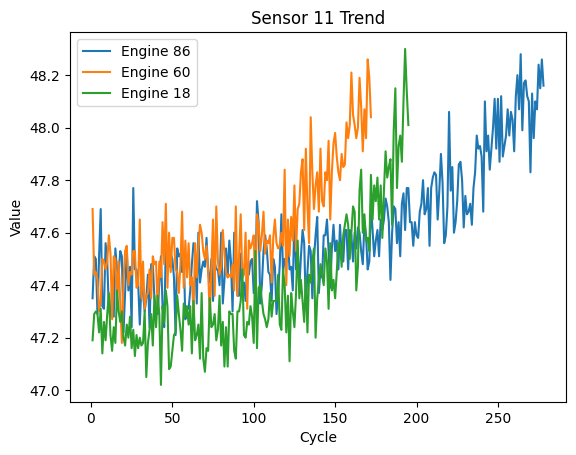

In [4]:
#Plot sensor trends (3 random engines)
import matplotlib.pyplot as plt

engines = np.random.choice(train['unit'].unique(), 3, replace=False)

for eng in engines:
    subset = train[train['unit'] == eng]
    plt.plot(subset['cycle'], subset['sensor_11'], label=f'Engine {eng}')

plt.legend()
plt.title("Sensor 11 Trend")
plt.xlabel("Cycle")
plt.ylabel("Value")
plt.show()

In [5]:
#Correlation with time (engine age)
corrs = train.corr(numeric_only=True)['cycle'].sort_values()

top_positive = corrs.tail(5)
top_negative = corrs.head(5)
print(corrs)
print("Positive:\n", top_positive)
print("Negative:\n", top_negative)

sensor_12      -0.611354
sensor_7       -0.595914
sensor_21      -0.585923
sensor_20      -0.583597
op_setting_1   -0.004527
op_setting_2    0.016132
unit            0.078753
sensor_6        0.105980
sensor_14       0.370324
sensor_9        0.443999
sensor_8        0.475977
sensor_13       0.477523
sensor_3        0.543947
sensor_2        0.549898
sensor_17       0.566995
sensor_15       0.588676
sensor_4        0.624577
sensor_11       0.634385
cycle           1.000000
op_setting_3         NaN
sensor_1             NaN
sensor_5             NaN
sensor_10            NaN
sensor_16            NaN
sensor_18            NaN
sensor_19            NaN
Name: cycle, dtype: float64
Positive:
 sensor_5    NaN
sensor_10   NaN
sensor_16   NaN
sensor_18   NaN
sensor_19   NaN
Name: cycle, dtype: float64
Negative:
 sensor_12      -0.611354
sensor_7       -0.595914
sensor_21      -0.585923
sensor_20      -0.583597
op_setting_1   -0.004527
Name: cycle, dtype: float64


In [6]:
#Part 2: Data Preprocessing & Feature Engineering
# Create RUL
max_cycle = train.groupby('unit')['cycle'].transform('max')
train['RUL'] = max_cycle - train['cycle']

In [7]:
#Drop low-variance sensors
variance = train.var(numeric_only=True)
low_var_cols = variance[variance < 1e-3].index

train = train.drop(columns=low_var_cols)
test = test.drop(columns=low_var_cols)

In [8]:
#Normalize features
from sklearn.preprocessing import StandardScaler

features = train.drop(columns=['unit','cycle','RUL']).columns

scaler = StandardScaler()

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [9]:
#Rolling window features (advanced)
window = 5

for col in ['sensor_11', 'sensor_12', 'sensor_7']:
    train[f'{col}_mean'] = train.groupby('unit')[col].rolling(window).mean().reset_index(0,drop=True)
    train[f'{col}_std']  = train.groupby('unit')[col].rolling(window).std().reset_index(0,drop=True)

train = train.fillna(0)

In [10]:
#Part 3: Model Building
# Group-aware split (IMPORTANT)
from sklearn.model_selection import GroupShuffleSplit

X = train.drop(columns=['RUL'])
y = train['RUL']
groups = train['unit']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, val_idx = next(gss.split(X, y, groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

In [11]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)
rf_mae = mean_absolute_error(y_val, rf_pred)

In [12]:
#XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_val)
xgb_mae = mean_absolute_error(y_val, xgb_pred)

In [13]:
#3. Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,5,7],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100,200]
}

grid = GridSearchCV(XGBRegressor(), param_grid, scoring='neg_mean_absolute_error', cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_


In [14]:
print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


In [15]:
#Part 4: Evaluation & Interpretation
# Test evaluation
from sklearn.metrics import mean_squared_error

preds = best_model.predict(X_val)

mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))

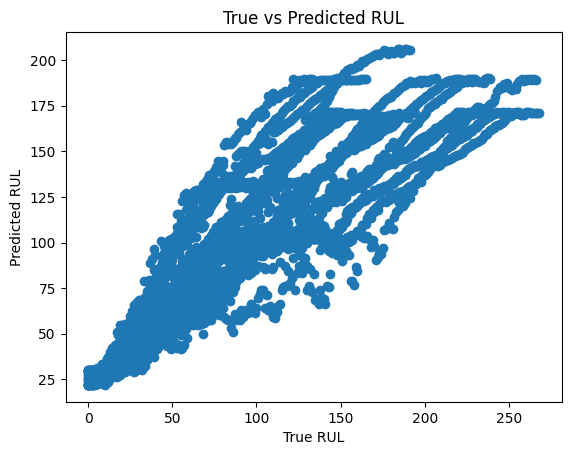

In [16]:
#2. True vs Predicted plot
plt.scatter(y_val, preds)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("True vs Predicted RUL")
plt.show()

In [17]:
#3. Feature importance
import pandas as pd

importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

,0
cycle,0.399900
sensor_11_mean,0.141443
sensor_4,0.097825
sensor_11,0.076302
sensor_7_mean,0.064988
sensor_9,0.039134
sensor_15,0.038504
unit,0.032771
sensor_12_mean,0.028790
sensor_20,0.027587


In [18]:
#Business Impact (critical threshold = 50)
threshold = 50

y_true_critical = (y_val <= threshold).astype(int)
y_pred_critical = (preds <= threshold).astype(int)

from sklearn.metrics import recall_score, confusion_matrix

recall = recall_score(y_true_critical, y_pred_critical)
cm = confusion_matrix(y_true_critical, y_pred_critical)

print("Recall:", recall)
print("Confusion Matrix:\n", cm)

Recall: 0.6607843137254902
Confusion Matrix:
 [[3040   10]
 [ 346  674]]
